### Tutorial of a Single-Objective Optimization Algorithm - Particle Swarm Optimization (PSO)

In [1]:
%load_ext autoreload
%autoreload 2


#### 1 Objective Functions for Optimization
* **Rastrigin Function (2D):** Input variables \( x, y \) in the range \([-5, 5]\)
* **Sphere Function (2D):** Input variables \( x, y \) in the range \([-5, 5]\)

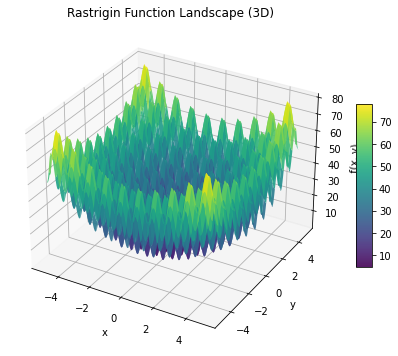

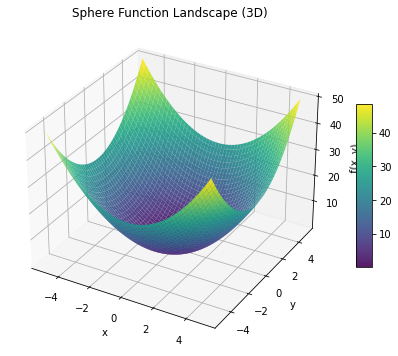

Global minimum of Rastrigin function: 0.0 at [0, 0]
Global minimum of Sphere function: 0 at [0, 0]


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Define the Rastrigin function
def rastrigin(X):
    """
    Computes the Rastrigin function for a set of input vectors.

    The Rastrigin function is a non-convex function used as a performance test problem for optimization algorithms.
    It is defined as:
        f(x) = A * n + sum_{i=1}^n [x_i^2 - A * cos(2 * pi * x_i)]
    where A = 10, n is the dimension of the input.

    Parameters
    ----------
    X : array-like, shape (n_particles, 2)
        Input array where each row represents a 2D point [x, y].

    Returns
    -------
    values : ndarray, shape (n_particles,)
        The Rastrigin function value for each input point.
    """
    A = 10
    return A * X.shape[1] + np.sum(X**2 - A * np.cos(2 * np.pi * X), axis=1)

# Define the Sphere function
def sphere(X):
    """
    Computes the Sphere function for a set of input vectors.

    The Sphere function is a simple convex function used as a benchmark in optimization.
    It is defined as:
        f(x) = sum_{i=1}^n x_i^2

    Parameters
    ----------
    X : array-like, shape (n_particles, 2)
        Input array where each row represents a 2D point [x, y].

    Returns
    -------
    values : ndarray, shape (n_particles,)
        The Sphere function value for each input point.
    """
    return np.sum(X**2, axis=1)

# Plotting the landscapes in 3D
def plot_function_landscape_3d(func, title, bounds=[-5, 5], resolution=200):
    x = np.linspace(bounds[0], bounds[1], resolution)
    y = np.linspace(bounds[0], bounds[1], resolution)
    X_grid, Y_grid = np.meshgrid(x, y)
    XY = np.stack([X_grid.ravel(), Y_grid.ravel()]).T
    Z = func(XY).reshape(X_grid.shape)

    fig = plt.figure(figsize=(8,6))
    ax = fig.add_subplot(111, projection='3d')
    surf = ax.plot_surface(X_grid, Y_grid, Z, cmap='viridis', edgecolor='none', alpha=0.9)
    ax.set_title(title)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('f(x, y)')
    fig.colorbar(surf, shrink=0.5, aspect=10)
    plt.show()

# Plot Rastrigin function landscape in 3D
plot_function_landscape_3d(rastrigin, "Rastrigin Function Landscape (3D)")

# Plot Sphere function landscape in 3D
plot_function_landscape_3d(sphere, "Sphere Function Landscape (3D)")

# Print the global minimum of the Rastrigin and Sphere functions
rastrigin_min = rastrigin(np.array([[0, 0]]))[0]
sphere_min = sphere(np.array([[0, 0]]))[0]
print(f"Global minimum of Rastrigin function: {rastrigin_min} at [0, 0]")
print(f"Global minimum of Sphere function: {sphere_min} at [0, 0]")



#### 2 Implement a PSO algorithm using pyswarms
 * Packages like pyswarms wrap the discussed steps into the object-oriented framework of python
 * Observe the animation: What can you observe from the population searching behaviors during iteration?

In [3]:
import numpy as np
import pyswarms as ps
import matplotlib.pyplot as plt
from matplotlib import animation

# Set random seed for reproducibility
np.random.seed(42)

# Define the 2-D Sphere function
def sphere(X):
    # X shape: (n_particles, dimensions)
    return np.sum(X**2, axis=1)

# PSO hyperparameters
dimensions = 2
bounds = (np.array([-5, -5]), np.array([5, 5]))
n_particles = 5
iters = 100

# fixed acceleration coefficients
c1 = 2.05
c2 = 2.05

# Velocity constraints
velocity_clamp = (-2, 2)

# Set up the optimizer with initial w (will be updated each iteration)
options = {'c1': c1, 'c2': c2, 'w': 0.9}

optimizer = ps.single.GlobalBestPSO(
    n_particles=n_particles,
    dimensions=dimensions,
    options=options,
    bounds=bounds,
    velocity_clamp=velocity_clamp
)

# Record the evolving process: store particle positions at each iteration
positions_history = []

# Custom optimization loop to apply linearly decreasing inertia
best_cost = None
for i in range(iters):
    # Linearly decrease inertia weight from 0.9 to 0.1
    w = 0.9 - (0.8 * i / (iters - 1))
    optimizer.options['w'] = w
    # Run one iteration at a time, record positions
    cost, pos = optimizer.optimize(
        sphere,
        iters=1,
        verbose=False
    )
    # Store current positions
    positions_history.append(optimizer.swarm.position.copy())
    if best_cost is None or cost < best_cost:
        best_cost = cost

print("Optimization complete! The best cost is", best_cost)

# The first position is not recorded before the first iteration, so add the initial position manually
positions_history.insert(0, optimizer.swarm.position.copy())


Optimization complete! The best cost is 2.180514007335968e-21


In [4]:
# Animate the cost history over iterations
import matplotlib.animation as animation
%matplotlib notebook

fig, ax = plt.subplots(figsize=(10, 8))
ax.set_xlabel('Iteration', fontsize=12)
ax.set_ylabel('Best Cost', fontsize=12)
ax.set_title('PSO on 2-D Sphere Function', fontsize=14)
ax.grid(True, linestyle='--', alpha=0.7)
line, = ax.plot([], [], linewidth=2)
ax.set_xlim(0, len(optimizer.cost_history))
# Set y-axis to log scale
ax.set_yscale('log')
# Avoid log(0) by setting lower limit to a small positive value if needed
min_cost = np.min(optimizer.cost_history)
if min_cost <= 0:
    min_cost = 1e-12
ax.set_ylim(min_cost, np.max(optimizer.cost_history)*1.05)
plt.tight_layout()

def init():
    line.set_data([], [])
    return line,

def animate(i):
    x = np.arange(i+1)
    y = optimizer.cost_history[:i+1]
    line.set_data(x, y)
    return line,

ani = animation.FuncAnimation(
    fig, animate, frames=len(optimizer.cost_history), init_func=init,
    blit=True, interval=100, repeat=False
)

plt.show()
ani.save('pso_sphere_cost_history.gif', writer='pillow', fps=10)

# --- Animation of PSO search process (2D, for Sphere function) ---

import matplotlib.animation as animation

def create_pso_animation(positions_history, sphere, bounds, iters, filename='pso_sphere_search.gif', fps=10):
    fig, ax = plt.subplots(figsize=(10, 8))
    x = np.linspace(bounds[0][0], bounds[1][0], 200)
    y = np.linspace(bounds[0][1], bounds[1][1], 200)
    X, Y = np.meshgrid(x, y)
    Z = X**2 + Y**2
    contour = ax.contourf(X, Y, Z, levels=50, cmap='viridis', alpha=0.7)
    cbar = plt.colorbar(contour, ax=ax)
    cbar.set_label('Sphere Value', fontsize=11)

    scat = ax.scatter([], [], c='red', s=60, edgecolor='k', label='Particles')
    gbest_point, = ax.plot([], [], 'b*', markersize=18, label='Global Best')

    ax.set_xlim(bounds[0][0], bounds[1][0])
    ax.set_ylim(bounds[0][1], bounds[1][1])
    ax.set_xlabel('x1', fontsize=12)
    ax.set_ylabel('x2', fontsize=12)
    ax.set_title('PSO Searching Process on Sphere Function', fontsize=14)
    ax.legend(loc='upper right', fontsize=11)

    # Styled text label for iteration number
    iteration_text = ax.text(
        0.04, 0.95, "", transform=ax.transAxes, fontsize=12,
        bbox=dict(boxstyle="round,pad=0.3", edgecolor='black', facecolor='white', alpha=0.7)
    )

    def init():
        scat.set_offsets(np.empty((0, 2)))
        gbest_point.set_data([], [])
        iteration_text.set_text("")
        return scat, gbest_point, iteration_text

    def animate(i):
        pos = positions_history[i]
        scat.set_offsets(pos)
        # Global best position at this iteration
        all_positions = np.vstack(positions_history[:i+1])
        all_costs = sphere(all_positions)
        idx = np.argmin(all_costs)
        gbest = all_positions[idx]
        gbest_point.set_data(gbest[0], gbest[1])
        ax.set_title('PSO Searching Process on Sphere Function', fontsize=14)
        iteration_text.set_text(f"Iteration: {i+1}/{iters}")
        return scat, gbest_point, iteration_text

    ani = animation.FuncAnimation(
        fig, animate, frames=len(positions_history),
        init_func=init, blit=True, interval=1000//fps, repeat=False
    )

    # Save animation as GIF
    ani.save(filename, writer='pillow', fps=fps)

    plt.show()
    return ani

# Generate and display the animation
create_pso_animation(positions_history, sphere, bounds, iters)

<IPython.core.display.Javascript object>

2026-03-16 21:02:46,452 - matplotlib.animation - INFO - Animation.save using <class 'matplotlib.animation.PillowWriter'>


<IPython.core.display.Javascript object>

2026-03-16 21:03:02,875 - matplotlib.animation - INFO - Animation.save using <class 'matplotlib.animation.PillowWriter'>
C:\Temp/ipykernel_24364/3111674393.py:83: MatplotlibDeprecationWarning: Setting data with a non sequence type is deprecated since 3.7 and will be remove two minor releases later
  gbest_point.set_data(gbest[0], gbest[1])


In [5]:
import numpy as np
import pyswarms as ps
import matplotlib.pyplot as plt
from matplotlib import animation

# Set random seed for reproducibility
np.random.seed(42)

# Define the 2-D Rastrigin function
def rastrigin(X):
    # X shape: (n_particles, dimensions)
    A = 10
    return A * X.shape[1] + np.sum(X**2 - A * np.cos(2 * np.pi * X), axis=1)

# PSO hyperparameters
dimensions = 2
bounds = (np.array([-5, -5]), np.array([5, 5]))
n_particles = 5
iters = 100

# fixed acceleration coefficients
c1 = 2.05
c2 = 2.05

# Velocity constraints
velocity_clamp = (-1, 1)

# Set up the optimizer with initial inertia weight (will be updated each iteration)
options = {'c1': c1, 'c2': c2, 'w': 0.4}

optimizer = ps.single.GlobalBestPSO(
    n_particles=n_particles,
    dimensions=dimensions,
    options=options,
    bounds=bounds,
    velocity_clamp=velocity_clamp
)

# Record the evolving process: store particle positions at each iteration
positions_history = []

# Custom optimization loop to implement linearly decreasing inertia
best_cost = None
for i in range(iters):
    # Linearly decrease inertia weight from 0.9 to 0.7
    w = 0.4 - (0.3 * i / (iters - 1))
#     w = 0.9
    optimizer.options['w'] = w
    # Run one iteration at a time, record positions
    cost, pos = optimizer.optimize(rastrigin, iters=1, verbose=False)
    positions_history.append(optimizer.swarm.position.copy())
    if best_cost is None or cost < best_cost:
        best_cost = cost

print("Optimization complete! The best cost is", best_cost)


Optimization complete! The best cost is 8.954601241490938


In [6]:
# Animate the cost history over iterations
import matplotlib.animation as animation

fig, ax = plt.subplots(figsize=(10, 8))
ax.set_xlabel('Iteration', fontsize=12)
ax.set_ylabel('Best Cost', fontsize=12)
ax.set_title('PSO on 2-D Rastrigin Function', fontsize=14)
ax.grid(True, linestyle='--', alpha=0.7)
line, = ax.plot([], [], linewidth=2)
ax.set_xlim(0, len(optimizer.cost_history))
# Set y-axis to log scale
ax.set_yscale('log')
# Avoid log(0) by setting lower limit to a small positive value if needed
min_cost = np.min(optimizer.cost_history)
if min_cost <= 0:
    min_cost = 1e-12
ax.set_ylim(min_cost, np.max(optimizer.cost_history)*1.05)
plt.tight_layout()

def init():
    line.set_data([], [])
    return line,

def animate(i):
    x = np.arange(i+1)
    y = optimizer.cost_history[:i+1]
    line.set_data(x, y)
    return line,

ani = animation.FuncAnimation(
    fig, animate, frames=len(optimizer.cost_history), init_func=init,
    blit=True, interval=100, repeat=False
)

plt.show()
ani.save('pso_rastrigin_cost_history.gif', writer='pillow', fps=10)

# --- Animation of PSO search process (2D, for Rastrigin function) ---

import matplotlib.animation as animation

def create_pso_animation(positions_history, rastrigin, bounds, iters, filename='pso_rastrigin_search.gif', fps=10):
    fig, ax = plt.subplots(figsize=(10, 8))
    x = np.linspace(bounds[0][0], bounds[1][0], 200)
    y = np.linspace(bounds[0][1], bounds[1][1], 200)
    X, Y = np.meshgrid(x, y)
    # Evaluate Rastrigin on a grid: shape (200, 200, 2) -> (200, 200)
    grid_points = np.stack([X, Y], axis=-1)  # shape (200, 200, 2)
    Z = rastrigin(grid_points.reshape(-1, 2)).reshape(X.shape)
    contour = ax.contourf(X, Y, Z, levels=50, cmap='viridis', alpha=0.7)
    cbar = plt.colorbar(contour, ax=ax)
    cbar.set_label('Rastrigin Value', fontsize=11)

    scat = ax.scatter([], [], c='red', s=60, edgecolor='k', label='Particles')
    gbest_point, = ax.plot([], [], 'b*', markersize=18, label='Global Best')

    ax.set_xlim(bounds[0][0], bounds[1][0])
    ax.set_ylim(bounds[0][1], bounds[1][1])
    ax.set_xlabel('x1', fontsize=12)
    ax.set_ylabel('x2', fontsize=12)
    ax.set_title('PSO Searching Process on Rastrigin Function', fontsize=14)
    ax.legend(loc='upper right', fontsize=11)

    # Styled text label for iteration number
    iteration_text = ax.text(
        0.04, 0.95, "", transform=ax.transAxes, fontsize=12,
        bbox=dict(boxstyle="round,pad=0.3", edgecolor='black', facecolor='white', alpha=0.7)
    )

    def init():
        scat.set_offsets(np.empty((0, 2)))
        gbest_point.set_data([], [])
        iteration_text.set_text("")
        return scat, gbest_point, iteration_text

    def animate(i):
        pos = positions_history[i]
        scat.set_offsets(pos)
        # Global best position at this iteration
        all_positions = np.vstack(positions_history[:i+1])
        all_costs = rastrigin(all_positions)
        idx = np.argmin(all_costs)
        gbest = all_positions[idx]
        gbest_point.set_data(gbest[0], gbest[1])
        ax.set_title('PSO Searching Process on Rastrigin Function', fontsize=14)
        iteration_text.set_text(f"Iteration: {i+1}/{iters}")
        return scat, gbest_point, iteration_text

    ani = animation.FuncAnimation(
        fig, animate, frames=len(positions_history),
        init_func=init, blit=True, interval=1000//fps, repeat=False
    )

    # Save animation as GIF
    ani.save(filename, writer='pillow', fps=fps)

    plt.show()
    return ani

# Generate and display the animation
create_pso_animation(positions_history, rastrigin, bounds, iters)

<IPython.core.display.Javascript object>

2026-03-16 21:03:36,695 - matplotlib.animation - INFO - Animation.save using <class 'matplotlib.animation.PillowWriter'>


<IPython.core.display.Javascript object>

2026-03-16 21:03:55,723 - matplotlib.animation - INFO - Animation.save using <class 'matplotlib.animation.PillowWriter'>
C:\Temp/ipykernel_24364/239420428.py:84: MatplotlibDeprecationWarning: Setting data with a non sequence type is deprecated since 3.7 and will be remove two minor releases later
  gbest_point.set_data(gbest[0], gbest[1])


#### 3 Comparison among Linear Programming, Nonlinear Programming, and Another Meta-Heuristic Algorithm (Differential Evolution)

In [7]:
import numpy as np
from scipy.optimize import minimize, differential_evolution, linprog
import matplotlib.pyplot as plt

# Set dimensionality
dim = 10

# Define the 10-D Rastrigin function
def rastrigin(X):
    X = np.asarray(X)
    A = 10
    return A * len(X) + np.sum(X**2 - A * np.cos(2 * np.pi * X))

# --- Linear Programming (Simplex) ---
# LP can only handle linear objectives, so we minimize c^T x as a baseline
c = np.ones(dim)
lp_bounds = [(-5.12, 5.12)] * dim
res_lp = linprog(c, bounds=lp_bounds, method='highs')
lp_x = res_lp.x if res_lp.success else np.array([np.nan] * dim)
lp_fx = rastrigin(lp_x) if res_lp.success else np.nan

print("LP (Simplex, linear baseline) result:")
print("  x* =", lp_x)
print("  f(x*) =", lp_fx)
print("  Success:", res_lp.success)

# --- Lagrange method (using SLSQP with equality constraint sum(x) = 0) ---
def constraint_eq(x):
    return np.sum(x)

# Use a good initial guess: small values summing to zero, e.g., half +0.5, half -0.5
x0 = np.random.uniform(-5.12, 5.12, dim)
cons = {'type': 'eq', 'fun': constraint_eq}
res_lagrange = minimize(rastrigin, x0, method='SLSQP', bounds=lp_bounds, constraints=cons)
print("\nLagrange (SLSQP with constraint sum(x)=0) result:")
print("  x* =", res_lagrange.x)
print("  f(x*) =", res_lagrange.fun)
print("  Success:", res_lagrange.success)

# --- Gradient-based optimization (BFGS) ---
x0 = np.array([3.0] * dim)
res_bfgs = minimize(rastrigin, x0, method='BFGS')
print("\nGradient-based (BFGS) result:")
print("  x* =", res_bfgs.x)
print("  f(x*) =", res_bfgs.fun)
print("  Success:", res_bfgs.success)

# --- Nelder-Mead optimization ---
x0 = np.array([3.0] * dim)
res_nm = minimize(rastrigin, x0, method='Nelder-Mead')
print("\nNelder-Mead result:")
print("  x* =", res_nm.x)
print("  f(x*) =", res_nm.fun)
print("  Success:", res_nm.success)

# --- Particle Swarm Optimization (PSO) using pyswarms ---
import pyswarms as ps

def rastrigin_pso(X):
    # X shape: (n_particles, dimensions)
    A = 10
    return A * X.shape[1] + np.sum(X**2 - A * np.cos(2 * np.pi * X), axis=1)

# Linearly decreasing inertia weight from 0.9 to 0.1 over 100 iterations
w_max = 0.9
w_min = 0.1
iters = 100
options = {'c1': 2.05, 'c2': 2.05, 'w': w_max}
# velocity_clamp = (-0.5, 0.5)  # Set velocity limits for each dimension

optimizer = ps.single.GlobalBestPSO(
    n_particles=10,
    dimensions=dim,
    options=options,
    bounds=(np.array([-5.12] * dim), np.array([5.12] * dim)),
    velocity_clamp=None
)

def linearly_decreasing_w(iteration, iters, w_max, w_min):
    return w_max - (w_max - w_min) * (iteration / (iters - 1))

# Since pyswarms' optimize() does not accept a callback argument,
# we must manually step through the optimization loop to update inertia weight.
cost_history = []
pos_history = []

# Use the public optimize() method instead of the private _step() method
for i in range(iters):
    # Update inertia weight linearly
    new_w = linearly_decreasing_w(i, iters, w_max, w_min)
    optimizer.options['w'] = new_w

    # Perform one optimization step using the public optimize() method
    cost, pos = optimizer.optimize(rastrigin_pso, iters=1, verbose=False)

    # Store current best cost and position
    cost_history.append(cost)
    pos_history.append(pos.copy())

    # Optionally print progress
    if (i+1) % 10 == 0 or i == 0 or i == iters-1:
        print(f"Iteration {i+1}/{iters}, inertia w={new_w:.3f}, best cost={cost:.6f}")

print("\nPSO (pyswarms, linearly decreasing inertia) result:")
print("  x* =", pos)
print("  f(x*) =", cost)


d:\Anaconda\lib\site-packages\scipy\optimize\_optimize.py:353: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  warnings.warn("Values in x were outside bounds during a "


LP (Simplex, linear baseline) result:
  x* = [-5.12 -5.12 -5.12 -5.12 -5.12 -5.12 -5.12 -5.12 -5.12 -5.12]
  f(x*) = 289.247137257859
  Success: True

Lagrange (SLSQP with constraint sum(x)=0) result:
  x* = [ 3.97979159e+00  1.98993043e+00 -9.94961630e-01 -3.97980822e+00
  3.97978592e+00  1.18330234e-05 -1.98991259e+00  1.84475747e-05
 -9.94932424e-01 -1.98992336e+00]
  f(x*) = 61.687143516016704
  Success: True

Gradient-based (BFGS) result:
  x* = [2.9848557 2.9848557 2.9848557 2.9848557 2.9848557 2.9848557 2.9848557
 2.9848557 2.9848557 2.9848557]
  f(x*) = 89.54601241487013
  Success: True

Nelder-Mead result:
  x* = [2.98480271 2.98486807 2.98485816 2.98488075 2.98490208 2.98483166
 2.98485328 2.98483955 2.98485632 2.98483581]
  f(x*) = 89.54601379462386
  Success: True
Iteration 1/100, inertia w=0.900, best cost=102.707787
Iteration 10/100, inertia w=0.827, best cost=91.429864
Iteration 20/100, inertia w=0.746, best cost=91.429864
Iteration 30/100, inertia w=0.666, best cost=75.